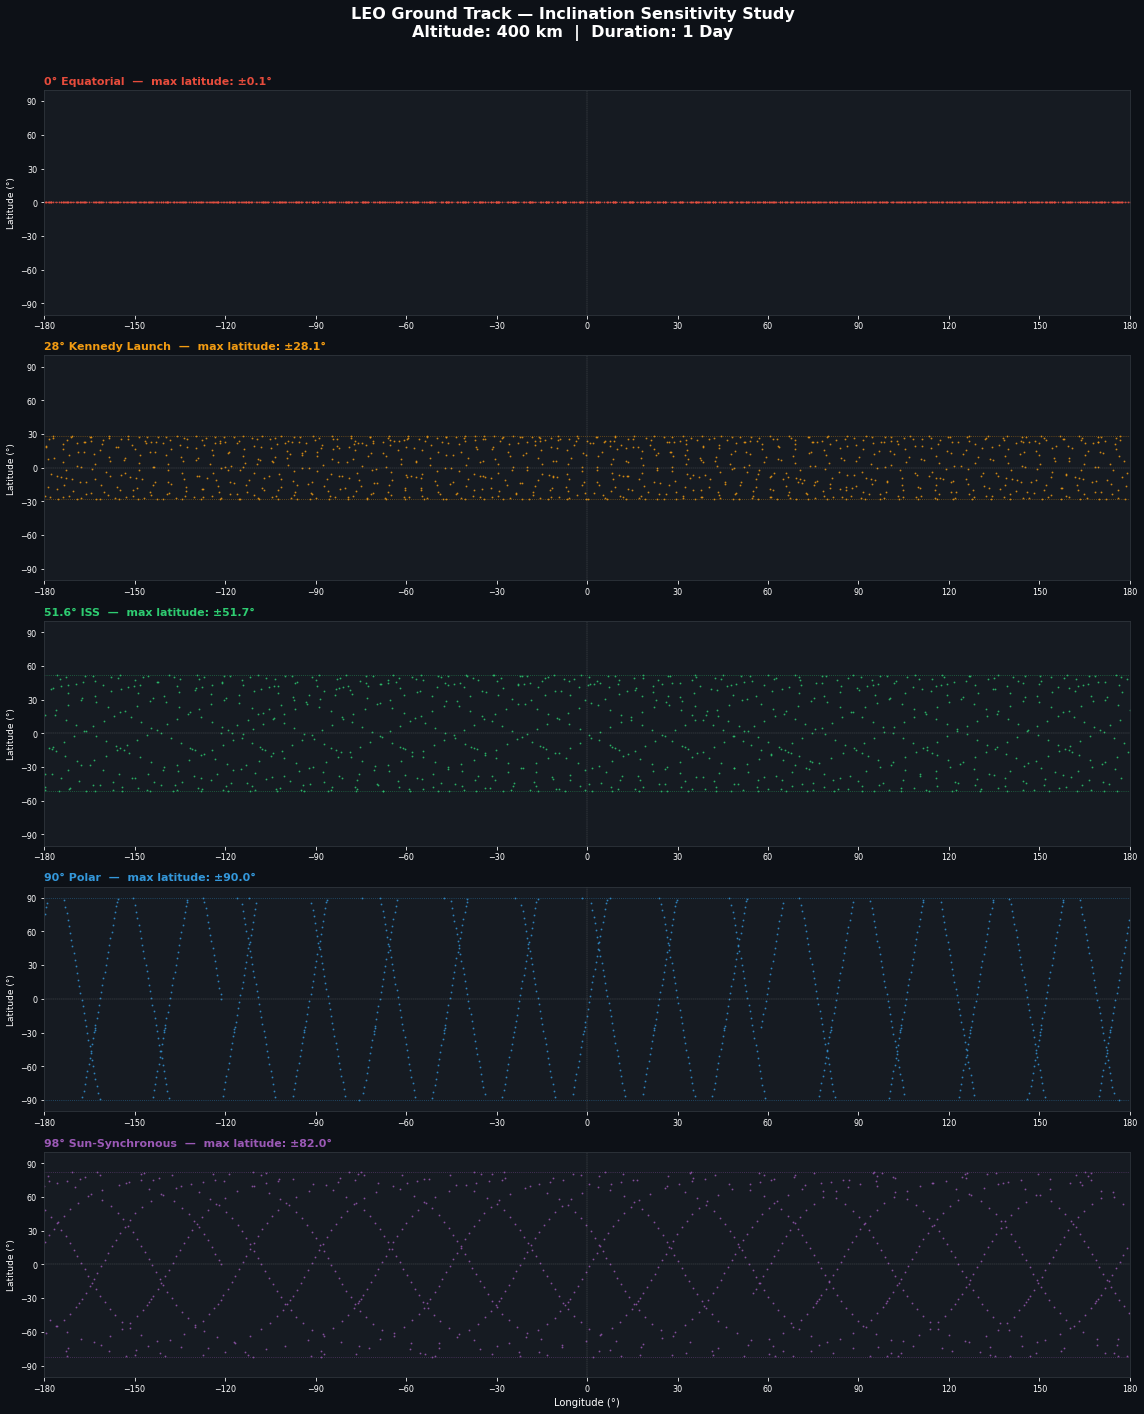

Plot saved to: D:\Space Softwares\GMAT Project\Inclination Study\Output\inclination_study.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# ── CONFIG ────────────────────────────────────────────────────────────────────
output_dir = r'D:\Space Softwares\GMAT Project\Inclination Study\Output'

# Match these EXACTLY to your actual filenames
files = {
    '0° Equatorial':      'Inclination_000_data.txt',
    '28° Kennedy Launch': 'Inclination_028_data.txt',
    '51.6° ISS':          'Inclination_051_data.txt',
    '90° Polar':          'Inclination_090_data.txt',
    '98° Sun-Synchronous':'Inclination_098_data.txt',
}

colors = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB', '#9B59B6']

def load_gmat_report(filepath):
    """
    GMAT UTCGregorian column contains spaces (e.g. '22 Jan 2025 00:00:00.000'),
    which breaks simple whitespace splitting. We read it as fixed-width-ish by
    splitting from the RIGHT since Lat and Lon are always the last 2 numeric tokens.
    """
    rows = []
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]  # skip header
        for line in lines:
            parts = line.split()
            if len(parts) < 6:
                continue
            lat = float(parts[-2])
            lon = float(parts[-1])
            rows.append((lat, lon))
    return pd.DataFrame(rows, columns=['Lat', 'Lon'])

# ── PLOT SETUP ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(16, 20))
fig.suptitle('LEO Ground Track — Inclination Sensitivity Study\nAltitude: 400 km  |  Duration: 1 Day',
             fontsize=16, fontweight='bold', y=0.98, color='white')
fig.patch.set_facecolor('#0D1117')

for ax, (label, filename), color in zip(axes, files.items(), colors):
    filepath = os.path.join(output_dir, filename)

    try:
        df = load_gmat_report(filepath)

        ax.set_facecolor('#161B22')
        ax.scatter(df['Lon'], df['Lat'], s=0.8, color=color, alpha=0.7)

        ax.axhline(0, color='white', linewidth=0.4, alpha=0.3, linestyle='--')
        ax.axvline(0, color='white', linewidth=0.4, alpha=0.3, linestyle='--')

        max_lat = df['Lat'].max()
        ax.axhline(max_lat,  color=color, linewidth=0.8, alpha=0.5, linestyle=':')
        ax.axhline(-max_lat, color=color, linewidth=0.8, alpha=0.5, linestyle=':')

        ax.set_xlim(-180, 180)
        ax.set_ylim(-100, 100)
        ax.set_ylabel('Latitude (°)', color='white', fontsize=9)
        ax.set_title(f'{label}  —  max latitude: ±{max_lat:.1f}°',
                     color=color, fontsize=11, fontweight='bold', loc='left', pad=6)
        ax.tick_params(colors='white', labelsize=8)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(30))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(30))
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363D')

    except FileNotFoundError:
        ax.set_facecolor('#161B22')
        ax.text(0.5, 0.5, f'File not found: {filename}', color='red',
                ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_title(label, color=color, fontsize=11)

axes[-1].set_xlabel('Longitude (°)', color='white', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])

savepath = os.path.join(output_dir, 'inclination_study.png')
plt.savefig(savepath, dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(f'Plot saved to: {savepath}')